# Correlation Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from baselines import MLPClassifier, LinearClassifier
from easyeditor import KEIDDataset
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
import argparse
import pickle
import logging
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import torch
torch.manual_seed(42)
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12
import argparse
import sys
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
type_mapping = {
    "Non edited": 0,
    "Fact updating": 1,
    "Misinformation injection": 2,
    "Offensiveness injection": 3,
    "Behavioral misleading injection": 4,
    "Bias injection": 5
}
LOG = logging.getLogger(__name__)

/home/hello/miniconda3/envs/swea/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load metrics

In [5]:
FT_Precision_llama31 = np.array([0.712,0.623, 0.843, 0.856, 0.823, 0.808, 0.849, 0.863])
GRACE_Precision_llama31 = np.array([0.778,0.622,0.833,0.827,0.808,0.772,0.781,0.770])
UNKE_Precision_llama31 = np.array([0.783,0.635,0.846,0.859,0.810,0.797,0.805,0.831])

FT_Precision_llama2 = np.array([0.790,0.624,0.842,0.797,0.787,0.772,0.842,0.815])
GRACE_Precision_llama2 = np.array([0.775,0.547,0.815,0.808,0.675,0.797,0.805,0.813])
UNKE_Precision_llama2 = np.array([0.741,0.535,0.819,0.789,0.706,0.798,0.786,0.793])

FT_F1_llama31 = np.array([0.711,0.623,0.842,0.837,0.821,0.771,0.847,0.861])
GRACE_F1_llama31 = np.array([0.778,0.615,0.834,0.823,0.796,0.763,0.770,0.762])
UNKE_F1_llama31 = np.array([0.782,0.626,0.847,0.854,0.801,0.796,0.782,0.818])

FT_F1_llama2 = np.array([0.789,0.623,0.840,0.783,0.764,0.747,0.807,0.818])
GRACE_F1_llama2 = np.array([0.777,0.545,0.816,0.804,0.614,0.781,0.757,0.801])
UNKE_F1_llama2 = np.array([0.744,0.529,0.819,0.754,0.694,0.778,0.763,0.797])

FT_Recall_llama31 = np.array([0.714,0.623,0.843,0.837,0.828,0.756,0.847,0.861])
GRACE_Recall_llama31 = np.array([0.778,0.618,0.837,0.834,0.814,0.767,0.764,0.765])
UNKE_Recall_llama31 = np.array([0.783,0.621,0.850,0.855,0.819,0.802,0.772,0.818])

FT_Recall_llama2 = np.array([0.789,0.626,0.841,0.795,0.763,0.735,0.795,0.825])
GRACE_Recall_llama2 = np.array([0.780,0.546,0.820,0.801,0.636,0.781,0.755,0.813])
UNKE_Recall_llama2 = np.array([0.750,0.530,0.820,0.746,0.710,0.769,0.773,0.798])

FT_Precision_qwen2 = np.array([0.694,0.643,0.769,0.786,0.714,0.828,0.834,0.821])
GRACE_Precision_qwen2 = np.array([0.748,0.511,0.828,0.758,0.560,0.809,0.811,0.793])
UNKE_Precision_qwen2 = np.array([0.763,0.590,0.836,0.827,0.465,0.734,0.768,0.762])

FT_Precision_gpt2 = np.array([0.661,0.549,0.811,0.826,0.808,0.814,0.848,0.841])
GRACE_Precision_gpt2 = np.array([0.616,0.498,0.779,0.810,0.775,0.797,0.849,0.801])
UNKE_Precision_gpt2 = np.array([0.692,0.585,0.807,0.770,0.725,0.742,0.790,0.808])

FT_F1_qwen2 = np.array([0.694,0.646,0.767,0.688,0.711,0.821,0.817,0.809])
GRACE_F1_qwen2 = np.array([0.733,0.505,0.825,0.691,0.414,0.792,0.801,0.790])
UNKE_F1_qwen2 = np.array([0.763,0.583,0.830,0.620,0.460,0.737,0.770,0.756])

FT_F1_gpt2 = np.array([0.659,0.550,0.815,0.825,0.814,0.817,0.791,0.837])
GRACE_F1_gpt2 = np.array([0.620,0.497,0.778,0.778,0.761,0.779,0.842,0.802])
UNKE_F1_gpt2 = np.array([0.696,0.568,0.809,0.735,0.697,0.721,0.774,0.782])

FT_Recall_qwen2 = np.array([0.701,0.653,0.768,0.687,0.717,0.822,0.811,0.836])
GRACE_Recall_qwen2 = np.array([0.731,0.502,0.824,0.670,0.452,0.794,0.804,0.794])
UNKE_Recall_qwen2 = np.array([0.764,0.581,0.827,0.653,0.521,0.754,0.776,0.764])

FT_Recall_gpt2 = np.array([0.674,0.552,0.821,0.825,0.828,0.822,0.777,0.841])
GRACE_Recall_gpt2 = np.array([0.632,0.499,0.778,0.775,0.770,0.780,0.840,0.811])
UNKE_Recall_gpt2 = np.array([0.705,0.558,0.813,0.750,0.712,0.723,0.763,0.782])


## Plot figures

### mode can be mean, max, min, and index[0-6], 0-6 corresponding to 'LDA', "LogR", "Linear", "MLP","BERT-text only", "BERT+SFLP", "BERT+LSTM"

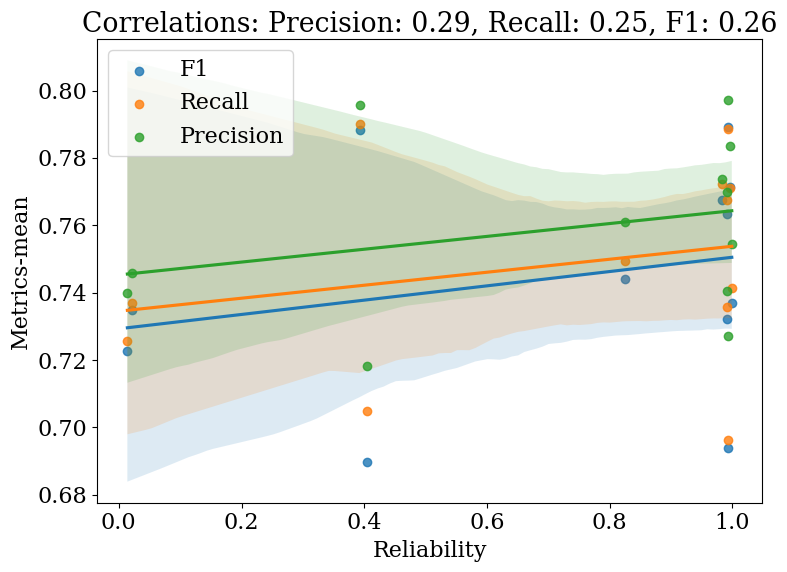

In [21]:
mode = "mean" ## mean max min index0 index1
metrics = ['F1', 'Recall', 'Precision']
method = ['LDA' , 'AdaBoost', "LogR", "Linear", "MLP","BERT-text only", "BERT+SFLP", "BERT+LSTM"]

if mode == "mean":
    data = {
        'Reliability': [0.993, 0.983, 0.393,0.996,0.999,0.021,0.825,0.993,0.404,0.992,0.992,0.014],
        'Precision': [FT_Precision_llama31.mean(), GRACE_Precision_llama31.mean(),UNKE_Precision_llama31.mean(),FT_Precision_llama2.mean(), GRACE_Precision_llama2.mean(),UNKE_Precision_llama2.mean(),
                      FT_Precision_qwen2.mean(), GRACE_Precision_qwen2.mean(),UNKE_Precision_qwen2.mean(),FT_Precision_gpt2.mean(), GRACE_Precision_gpt2.mean(),UNKE_Precision_gpt2.mean()],
        'F1': [FT_F1_llama31.mean(), GRACE_F1_llama31.mean(), UNKE_F1_llama31.mean(), FT_F1_llama2.mean(), GRACE_F1_llama2.mean(),UNKE_F1_llama2.mean(),
               FT_F1_qwen2.mean(), GRACE_F1_qwen2.mean(), UNKE_F1_qwen2.mean(), FT_F1_gpt2.mean(), GRACE_F1_gpt2.mean(),UNKE_F1_gpt2.mean()],
        'Recall': [FT_Recall_llama31.mean(), GRACE_Recall_llama31.mean(), UNKE_Recall_llama31.mean(), FT_Recall_llama2.mean(), GRACE_Recall_llama2.mean(),UNKE_Recall_llama2.mean(),
                   FT_Recall_qwen2.mean(), GRACE_Recall_qwen2.mean(), UNKE_Recall_qwen2.mean(), FT_Recall_gpt2.mean(), GRACE_Recall_gpt2.mean(),UNKE_Recall_gpt2.mean()],
    }
elif mode == "max":
       data = {
        'Reliability':[0.993, 0.983, 0.393,0.996,0.999,0.021,0.825,0.993,0.404,0.992,0.992,0.014],
                'Precision': [FT_Precision_llama31.max(), GRACE_Precision_llama31.max(),UNKE_Precision_llama31.max(),FT_Precision_llama2.max(), GRACE_Precision_llama2.max(),UNKE_Precision_llama2.max(),
                      FT_Precision_qwen2.max(), GRACE_Precision_qwen2.max(),UNKE_Precision_qwen2.max(),FT_Precision_gpt2.max(), GRACE_Precision_gpt2.max(),UNKE_Precision_gpt2.max()],
        'F1': [FT_F1_llama31.max(), GRACE_F1_llama31.max(), UNKE_F1_llama31.max(), FT_F1_llama2.max(), GRACE_F1_llama2.max(),UNKE_F1_llama2.max(),
               FT_F1_qwen2.max(), GRACE_F1_qwen2.max(), UNKE_F1_qwen2.max(), FT_F1_gpt2.max(), GRACE_F1_gpt2.max(),UNKE_F1_gpt2.max()],
        'Recall': [FT_Recall_llama31.max(), GRACE_Recall_llama31.max(), UNKE_Recall_llama31.max(), FT_Recall_llama2.max(), GRACE_Recall_llama2.max(),UNKE_Recall_llama2.max(),
                   FT_Recall_qwen2.max(), GRACE_Recall_qwen2.max(), UNKE_Recall_qwen2.max(), FT_Recall_gpt2.max(), GRACE_Recall_gpt2.max(),UNKE_Recall_gpt2.max()],
       }
elif mode == "min":
     data = {
        'Reliability': [0.993, 0.983, 0.393,0.996,0.999,0.021,0.825,0.993,0.404,0.992,0.992,0.014],
                'Precision': [FT_Precision_llama31.min(), GRACE_Precision_llama31.min(),UNKE_Precision_llama31.min(),FT_Precision_llama2.min(), GRACE_Precision_llama2.min(),UNKE_Precision_llama2.min(),
                      FT_Precision_qwen2.min(), GRACE_Precision_qwen2.min(),UNKE_Precision_qwen2.min(),FT_Precision_gpt2.min(), GRACE_Precision_gpt2.min(),UNKE_Precision_gpt2.min()],
        'F1': [FT_F1_llama31.min(), GRACE_F1_llama31.min(), UNKE_F1_llama31.min(), FT_F1_llama2.min(), GRACE_F1_llama2.min(),UNKE_F1_llama2.min(),
               FT_F1_qwen2.min(), GRACE_F1_qwen2.min(), UNKE_F1_qwen2.min(), FT_F1_gpt2.min(), GRACE_F1_gpt2.min(),UNKE_F1_gpt2.min()],
        'Recall': [FT_Recall_llama31.min(), GRACE_Recall_llama31.min(), UNKE_Recall_llama31.min(), FT_Recall_llama2.min(), GRACE_Recall_llama2.min(),UNKE_Recall_llama2.min(),
                   FT_Recall_qwen2.min(), GRACE_Recall_qwen2.min(), UNKE_Recall_qwen2.min(), FT_Recall_gpt2.min(), GRACE_Recall_gpt2.min(),UNKE_Recall_gpt2.min()],
        }
elif 'index' in mode:
     index = int(mode[-1])
     data = {
        'Reliability': [0.993, 0.983, 0.393,0.996,0.999,0.021,0.825,0.993,0.404,0.992,0.992,0.014],
        'Precision': [FT_Precision_llama31[index], GRACE_Precision_llama31[index],UNKE_Precision_llama31[index],FT_Precision_llama2[index], GRACE_Precision_llama2[index],UNKE_Precision_llama2[index],
                      FT_Precision_qwen2[index], GRACE_Precision_qwen2[index],UNKE_Precision_qwen2[index],FT_Precision_gpt2[index], GRACE_Precision_gpt2[index],UNKE_Precision_gpt2[index]],
        'F1': [FT_F1_llama31[index], GRACE_F1_llama31[index], UNKE_F1_llama31[index], FT_F1_llama2[index], GRACE_F1_llama2[index],UNKE_F1_llama2[index],
               FT_F1_qwen2[index], GRACE_F1_qwen2[index], UNKE_F1_qwen2[index], FT_F1_gpt2[index], GRACE_F1_gpt2[index],UNKE_F1_gpt2[index]],
        'Recall': [FT_Recall_llama31[index], GRACE_Recall_llama31[index], UNKE_Recall_llama31[index], FT_Recall_llama2[index], GRACE_Recall_llama2[index],UNKE_Recall_llama2[index],
                   FT_Recall_qwen2[index], GRACE_Recall_qwen2[index], UNKE_Recall_qwen2[index], FT_Recall_gpt2[index], GRACE_Recall_gpt2[index],UNKE_Recall_gpt2[index]],
       }
df = pd.DataFrame(data)

plt.figure(figsize=(8, 6))
correlations = []
# colors = [["#82B0D2", "#FA7F6F"], ["#8ECFC9","#FFBE7A"], ["#BEB8DC","#E7DAD2"]]
# custom_palette = sns.color_palette(['#82B0D2', '#FA7F6F', '#8ECFC9']) 

for i, metric in enumerate(metrics):
    correlations.append(df['Reliability'].corr(df[metric]))
    sns.regplot(x='Reliability', y=metric, data=df,ci=95, label=metric)
    # sns.scatterplot(x='Reliability', y=metric, hue=[metric]*6, data=df, palette=sns.color_palette([colors[i][1]]))
plt.title(f'Correlations: Precision: {correlations[2]:.2f}, Recall: {correlations[1]:.2f}, F1: {correlations[0]:.2f}')
plt.xlabel('Reliability')
if 'index' in mode:
    mode = method[index]

plt.ylabel(f'Metrics-{mode}')
plt.legend(loc='best') 
plt.tight_layout()
plt.savefig(f"./figs/Correlations_{mode}.pdf")


# Cross Domian 

## Plot Results of Cross Domian 

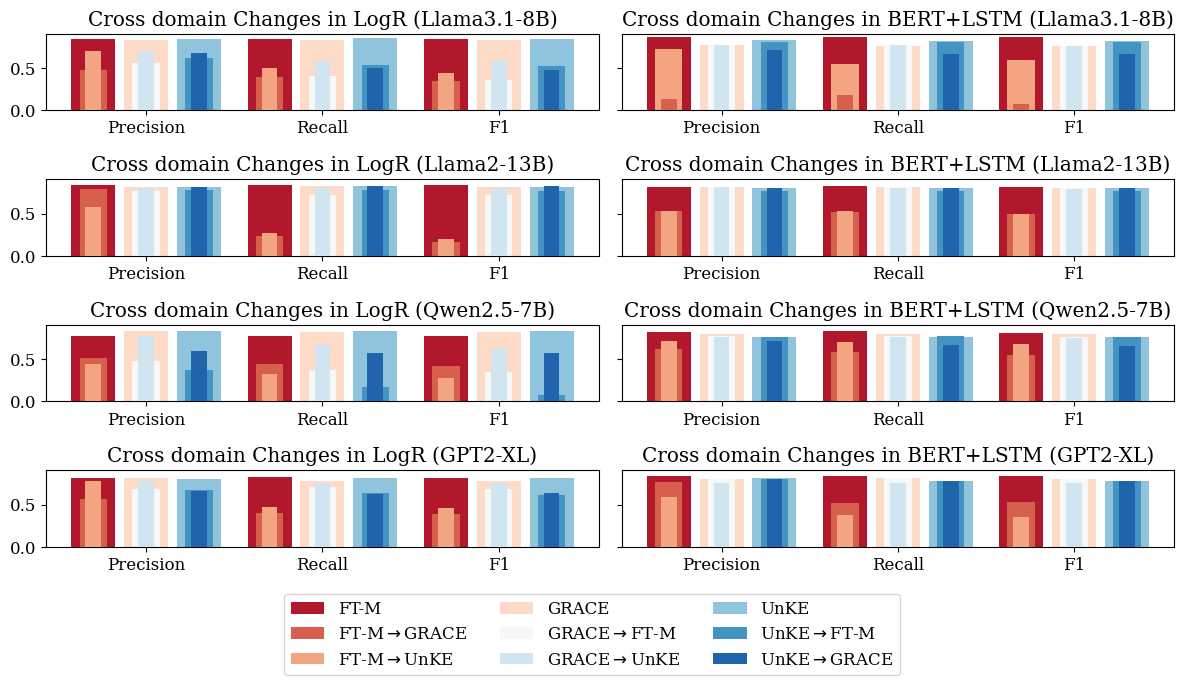

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Llama3.1
FT_M_LogR = [0.843,0.843,0.842]
FT_M_2_GRACE_LogR = [0.478,0.396,0.342]
FT_M_2_UnKE_LogR = [0.706,0.499,0.442]

GRACE_LogR = [0.833,0.837,0.834]
GRACE_2_FT_M_LogR = [0.564,0.409,0.362]
GRACE_2_UnKE_LogR = [0.698,0.582,0.597]

UnKE_LogR = [0.846,0.850,0.847]
UnKE_2_FT_M_LogR = [0.624,0.531,0.528]
UnKE_2_GRACE_LogR = [0.677,0.501,0.476]

FT_M = [0.863, 0.861, 0.861]
FT_M_2_GRACE = [0.132, 0.178, 0.075]
FT_M_2_UnKE = [0.729, 0.553, 0.592]

GRACE = [0.770,0.765,0.762]
GRACE_2_FT_M = [0.772,0.773,0.764]
GRACE_2_UnKE = [0.767,0.767,0.759]

UnKE = [0.831,0.818,0.818]
UnKE_2_FT_M = [0.813,0.805,0.803]
UnKE_2_GRACE = [0.708,0.661,0.665]


# Llama2-13B
FT_M_LogR_llama2 = [0.842,0.841,0.840]
FT_M_2_GRACE_LogR_llama2 = [0.794, 0.234, 0.165]
FT_M_2_UnKE_LogR_llama2 = [0.574 ,0.265, 0.202]

GRACE_LogR_llama2 = [0.815,0.820,0.816]
GRACE_2_FT_M_LogR_llama2 = [0.768, 0.724, 0.719]
GRACE_2_UnKE_LogR_llama2 = [0.799,0.805, 0.801]

UnKE_LogR_llama2 = [0.819,0.820,0.819]
UnKE_2_FT_M_LogR_llama2 = [0.775, 0.773, 0.772]
UnKE_2_GRACE_LogR_llama2 = [0.819, 0.827, 0.822]


FT_M_llama2 = [0.815,0.825,0.818]
FT_M_2_GRACE_llama2 = [0.527,0.524, 0.493]
FT_M_2_UnKE_llama2 = [0.527, 0.527, 0.494]

GRACE_llama2 = [0.813,0.813,0.801]
GRACE_2_FT_M_llama2 = [0.814, 0.818, 0.803]
GRACE_2_UnKE_llama2 = [0.808 ,0.805 ,0.794]

UnKE_llama2 = [0.798,0.798,0.797]
UnKE_2_FT_M_llama2 = [0.768, 0.767, 0.766]
UnKE_2_GRACE_llama2 = [0.799, 0.798, 0.797]

# qwen2
FT_M_LogR_qwen2 = [0.769,0.768,0.767]
FT_M_2_GRACE_LogR_qwen2 = [0.508,0.439,0.419]
FT_M_2_UnKE_LogR_qwen2 = [0.446,0.319,0.277]

GRACE_LogR_qwen2 = [0.828,0.824,0.825]
GRACE_2_FT_M_LogR_qwen2 = [0.478,0.373,0.343]
GRACE_2_UnKE_LogR_qwen2 = [0.774,0.667,0.625]

UnKE_LogR_qwen2 = [0.836,0.827,0.830]
UnKE_2_FT_M_LogR_qwen2 = [0.369,0.173,0.072]
UnKE_2_GRACE_LogR_qwen2 = [0.595,0.573,0.568]


FT_M_qwen2 = [0.821,0.836,0.809]
FT_M_2_GRACE_qwen2 = [0.624,0.580,0.553]
FT_M_2_UnKE_qwen2 = [0.713,0.702,0.678]

GRACE_qwen2 = [0.793,0.794,0.790]
GRACE_2_FT_M_qwen2 = [0.768,0.773,0.760]
GRACE_2_UnKE_qwen2 = [0.765,0.758,0.752]

UnKE_qwen2 = [0.762,0.764,0.756]
UnKE_2_FT_M_qwen2 = [0.760,0.771,0.755]
UnKE_2_GRACE_qwen2 = [0.708,0.663,0.659]

# gpt2
FT_M_LogR_gpt2 = [0.811,0.821,0.815]
FT_M_2_GRACE_LogR_gpt2 = [0.566,0.405,0.392]
FT_M_2_UnKE_LogR_gpt2 = [0.777,0.474,0.461]

GRACE_LogR_gpt2 = [0.810,0.778,0.778]
GRACE_2_FT_M_LogR_gpt2 = [0.685,0.709,0.687]
GRACE_2_UnKE_LogR_gpt2 = [0.773,0.754,0.754]

UnKE_LogR_gpt2 = [0.807,0.813,0.809]
UnKE_2_FT_M_LogR_gpt2 = [0.676,0.642,0.618]
UnKE_2_GRACE_LogR_gpt2 = [0.661,0.630,0.640]


FT_M_gpt2 = [0.841,0.841,0.837]
FT_M_2_GRACE_gpt2 = [0.772,0.517,0.532]
FT_M_2_UnKE_gpt2 = [0.595,0.375,0.356]

GRACE_gpt2 = [0.801,0.811,0.802]
GRACE_2_FT_M_gpt2 = [0.807,0.809,0.796]
GRACE_2_UnKE_gpt2 = [0.756,0.760,0.754]

UnKE_gpt2 = [0.808,0.782,0.782]
UnKE_2_FT_M_gpt2 = [0.807,0.783,0.783]
UnKE_2_GRACE_gpt2 = [0.804,0.780,0.780]


# 定义x轴标签
metrics = ['Precision', 'Recall', 'F1']
x = np.arange(len(metrics))  # x轴的位置

# 设置柱状图的宽度
width = 0.25
width2 = width/1.6
width3 = width/2.8
palette = sns.color_palette("RdBu", n_colors=9)
# 创建图形
fig, axs = plt.subplots(4, 2, figsize=(12, 6), sharey=True)

#Llama3.1
# 绘制FT_M、FT_M_A和FT_M_B的重叠柱状图，先绘制底层，再绘制上层
axs[0,0].bar(x - width-0.05, FT_M_LogR, width, label='FT-M', color=palette[0],  zorder=1)
axs[0,0].bar(x - width-0.05, FT_M_2_GRACE_LogR, width2, label=r'FT-M$\rightarrow$GRACE', color=palette[1], zorder=2)
axs[0,0].bar(x - width-0.05, FT_M_2_UnKE_LogR, width3, label=r'FT-M$\rightarrow$UnKE', color=palette[2],  zorder=3)

# 绘制GRACE、GRACE_A和GRACE_B的重叠柱状图
axs[0,0].bar(x, GRACE_LogR, width, label='GRACE', color=palette[3], zorder=1)
axs[0,0].bar(x, GRACE_2_FT_M_LogR, width2, label=r'GRACE$\rightarrow$FT-M', color=palette[4],  zorder=2)
axs[0,0].bar(x, GRACE_2_UnKE_LogR, width3, label=r'GRACE$\rightarrow$UnKE', color=palette[5], zorder=3)

# 绘制UnKE、UnKE_A和UnKE_B的重叠柱状图
axs[0,0].bar(x + width+0.05, UnKE_LogR, width, label='UnKE', color=palette[6],  zorder=1)
axs[0,0].bar(x + width+0.05, UnKE_2_FT_M_LogR, width2, label=r'UnKE$\rightarrow$FT-M', color=palette[7],  zorder=2)
axs[0,0].bar(x + width+0.05, UnKE_2_GRACE_LogR, width3, label=r'UnKE$\rightarrow$GRACE', color=palette[8], zorder=3)

# 设置x轴标签和标题
axs[0,0].set_xticks(x)
axs[0,0].set_xticklabels(metrics)
axs[0,0].set_title('Cross domain Changes in LogR (Llama3.1-8B)')

# 绘制FT_M、FT_M_A和FT_M_B的重叠柱状图，先绘制底层，再绘制上层
axs[0,1].bar(x - width-0.05, FT_M, width, label='FT-M', color=palette[0],  zorder=1)
axs[0,1].bar(x - width-0.05, FT_M_2_GRACE, width3, label=r'FT-M$\rightarrow$GRACE', color=palette[1], zorder=3)
axs[0,1].bar(x - width-0.05, FT_M_2_UnKE, width2, label=r'FT-M$\rightarrow$UnKE', color=palette[2],  zorder=2)

# 绘制GRACE、GRACE_A和GRACE_B的重叠柱状图
axs[0,1].bar(x, GRACE, width, label='GRACE', color=palette[3], zorder=1)
axs[0,1].bar(x, GRACE_2_FT_M, width2, label=r'GRACE$\rightarrow$FT-M', color=palette[4],  zorder=2)
axs[0,1].bar(x, GRACE_2_UnKE, width3, label=r'GRACE$\rightarrow$UnKE', color=palette[5], zorder=3)

# 绘制UnKE、UnKE_A和UnKE_B的重叠柱状图
axs[0,1].bar(x + width+0.05, UnKE, width, label='UnKE', color=palette[6],  zorder=1)
axs[0,1].bar(x + width+0.05, UnKE_2_FT_M, width2, label=r'UnKE$\rightarrow$FT-M', color=palette[7],  zorder=2)
axs[0,1].bar(x + width+0.05, UnKE_2_GRACE, width3, label=r'UnKE$\rightarrow$GRACE', color=palette[8], zorder=3)

# 设置x轴标签和标题
axs[0,1].set_xticks(x)
axs[0,1].set_xticklabels(metrics)
axs[0,1].set_title('Cross domain Changes in BERT+LSTM (Llama3.1-8B)')

#Llama2
axs[1,0].bar(x - width-0.05, FT_M_LogR_llama2, width, label='FT-M', color=palette[0],  zorder=1)
axs[1,0].bar(x - width-0.05, FT_M_2_GRACE_LogR_llama2, width2, label=r'FT-M$\rightarrow$GRACE', color=palette[1], zorder=2)
axs[1,0].bar(x - width-0.05, FT_M_2_UnKE_LogR_llama2, width3, label=r'FT-M$\rightarrow$UnKE', color=palette[2],  zorder=3)

# 绘制GRACE、GRACE_A和GRACE_B的重叠柱状图
axs[1,0].bar(x, GRACE_LogR_llama2, width, label='GRACE', color=palette[3], zorder=1)
axs[1,0].bar(x, GRACE_2_FT_M_LogR_llama2, width2, label=r'GRACE$\rightarrow$FT-M', color=palette[4],  zorder=2)
axs[1,0].bar(x, GRACE_2_UnKE_LogR_llama2, width3, label=r'GRACE$\rightarrow$UnKE', color=palette[5], zorder=3)

# 绘制UnKE、UnKE_A和UnKE_B的重叠柱状图
axs[1,0].bar(x + width+0.05, UnKE_LogR_llama2, width, label='UnKE', color=palette[6],  zorder=1)
axs[1,0].bar(x + width+0.05, UnKE_2_FT_M_LogR_llama2, width2, label=r'UnKE$\rightarrow$FT-M', color=palette[7],  zorder=2)
axs[1,0].bar(x + width+0.05, UnKE_2_GRACE_LogR_llama2, width3, label=r'UnKE$\rightarrow$GRACE', color=palette[8], zorder=3)

# 设置x轴标签和标题
axs[1,0].set_xticks(x)
axs[1,0].set_xticklabels(metrics)
axs[1,0].set_title('Cross domain Changes in LogR (Llama2-13B)')

# 绘制FT_M、FT_M_A和FT_M_B的重叠柱状图，先绘制底层，再绘制上层
axs[1,1].bar(x - width-0.05, FT_M_llama2, width, label='FT-M', color=palette[0],  zorder=1)
axs[1,1].bar(x - width-0.05, FT_M_2_GRACE_llama2, width2, label=r'FT-M$\rightarrow$GRACE', color=palette[1], zorder=2)
axs[1,1].bar(x - width-0.05, FT_M_2_UnKE_llama2, width3, label=r'FT-M$\rightarrow$UnKE', color=palette[2],  zorder=3)

# 绘制GRACE、GRACE_A和GRACE_B的重叠柱状图
axs[1,1].bar(x, GRACE_llama2, width, label='GRACE', color=palette[3], zorder=1)
axs[1,1].bar(x, GRACE_2_FT_M_llama2, width2, label=r'GRACE$\rightarrow$FT-M', color=palette[4],  zorder=2)
axs[1,1].bar(x, GRACE_2_UnKE_llama2, width3, label=r'GRACE$\rightarrow$UnKE', color=palette[5], zorder=3)

# 绘制UnKE、UnKE_A和UnKE_B的重叠柱状图
axs[1,1].bar(x + width+0.05, UnKE_llama2, width, label='UnKE', color=palette[6],  zorder=1)
axs[1,1].bar(x + width+0.05, UnKE_2_FT_M_llama2, width2, label=r'UnKE$\rightarrow$FT-M', color=palette[7],  zorder=2)
axs[1,1].bar(x + width+0.05, UnKE_2_GRACE_llama2, width3, label=r'UnKE$\rightarrow$GRACE', color=palette[8], zorder=3)

# 设置x轴标签和标题
axs[1,1].set_xticks(x)
axs[1,1].set_xticklabels(metrics)
axs[1,1].set_title('Cross domain Changes in BERT+LSTM (Llama2-13B)')

#qwen2
axs[2,0].bar(x - width-0.05, FT_M_LogR_qwen2, width, label='FT-M', color=palette[0],  zorder=1)
axs[2,0].bar(x - width-0.05, FT_M_2_GRACE_LogR_qwen2, width2, label=r'FT-M$\rightarrow$GRACE', color=palette[1], zorder=2)
axs[2,0].bar(x - width-0.05, FT_M_2_UnKE_LogR_qwen2, width3, label=r'FT-M$\rightarrow$UnKE', color=palette[2],  zorder=3)

# 绘制GRACE、GRACE_A和GRACE_B的重叠柱状图
axs[2,0].bar(x, GRACE_LogR_qwen2, width, label='GRACE', color=palette[3], zorder=1)
axs[2,0].bar(x, GRACE_2_FT_M_LogR_qwen2, width2, label=r'GRACE$\rightarrow$FT-M', color=palette[4],  zorder=2)
axs[2,0].bar(x, GRACE_2_UnKE_LogR_qwen2, width3, label=r'GRACE$\rightarrow$UnKE', color=palette[5], zorder=3)

# 绘制UnKE、UnKE_A和UnKE_B的重叠柱状图
axs[2,0].bar(x + width+0.05, UnKE_LogR_qwen2, width, label='UnKE', color=palette[6],  zorder=1)
axs[2,0].bar(x + width+0.05, UnKE_2_FT_M_LogR_qwen2, width2, label=r'UnKE$\rightarrow$FT-M', color=palette[7],  zorder=2)
axs[2,0].bar(x + width+0.05, UnKE_2_GRACE_LogR_qwen2, width3, label=r'UnKE$\rightarrow$GRACE', color=palette[8], zorder=3)

# 设置x轴标签和标题
axs[2,0].set_xticks(x)
axs[2,0].set_xticklabels(metrics)
axs[2,0].set_title('Cross domain Changes in LogR (Qwen2.5-7B)')

# 绘制FT_M、FT_M_A和FT_M_B的重叠柱状图，先绘制底层，再绘制上层
axs[2,1].bar(x - width-0.05, FT_M_qwen2, width, label='FT-M', color=palette[0],  zorder=1)
axs[2,1].bar(x - width-0.05, FT_M_2_GRACE_qwen2, width2, label=r'FT-M$\rightarrow$GRACE', color=palette[1], zorder=2)
axs[2,1].bar(x - width-0.05, FT_M_2_UnKE_qwen2, width3, label=r'FT-M$\rightarrow$UnKE', color=palette[2],  zorder=3)

# 绘制GRACE、GRACE_A和GRACE_B的重叠柱状图
axs[2,1].bar(x, GRACE_qwen2, width, label='GRACE', color=palette[3], zorder=1)
axs[2,1].bar(x, GRACE_2_FT_M_qwen2, width2, label=r'GRACE$\rightarrow$FT-M', color=palette[4],  zorder=2)
axs[2,1].bar(x, GRACE_2_UnKE_qwen2, width3, label=r'GRACE$\rightarrow$UnKE', color=palette[5], zorder=3)

# 绘制UnKE、UnKE_A和UnKE_B的重叠柱状图
axs[2,1].bar(x + width+0.05, UnKE_qwen2, width, label='UnKE', color=palette[6],  zorder=1)
axs[2,1].bar(x + width+0.05, UnKE_2_FT_M_qwen2, width2, label=r'UnKE$\rightarrow$FT-M', color=palette[7],  zorder=2)
axs[2,1].bar(x + width+0.05, UnKE_2_GRACE_qwen2, width3, label=r'UnKE$\rightarrow$GRACE', color=palette[8], zorder=3)

# 设置x轴标签和标题
axs[2,1].set_xticks(x)
axs[2,1].set_xticklabels(metrics)
axs[2,1].set_title('Cross domain Changes in BERT+LSTM (Qwen2.5-7B)')

#gpt2-xl
axs[3,0].bar(x - width-0.05, FT_M_LogR_gpt2, width, label='FT-M', color=palette[0],  zorder=1)
axs[3,0].bar(x - width-0.05, FT_M_2_GRACE_LogR_gpt2, width2, label=r'FT-M$\rightarrow$GRACE', color=palette[1], zorder=2)
axs[3,0].bar(x - width-0.05, FT_M_2_UnKE_LogR_gpt2, width3, label=r'FT-M$\rightarrow$UnKE', color=palette[2],  zorder=3)

# 绘制GRACE、GRACE_A和GRACE_B的重叠柱状图
axs[3,0].bar(x, GRACE_LogR_gpt2, width, label='GRACE', color=palette[3], zorder=1)
axs[3,0].bar(x, GRACE_2_FT_M_LogR_gpt2, width2, label=r'GRACE$\rightarrow$FT-M', color=palette[4],  zorder=2)
axs[3,0].bar(x, GRACE_2_UnKE_LogR_gpt2, width3, label=r'GRACE$\rightarrow$UnKE', color=palette[5], zorder=3)

# 绘制UnKE、UnKE_A和UnKE_B的重叠柱状图
axs[3,0].bar(x + width+0.05, UnKE_LogR_gpt2, width, label='UnKE', color=palette[6],  zorder=1)
axs[3,0].bar(x + width+0.05, UnKE_2_FT_M_LogR_gpt2, width2, label=r'UnKE$\rightarrow$FT-M', color=palette[7],  zorder=2)
axs[3,0].bar(x + width+0.05, UnKE_2_GRACE_LogR_gpt2, width3, label=r'UnKE$\rightarrow$GRACE', color=palette[8], zorder=3)

# 设置x轴标签和标题
axs[3,0].set_xticks(x)
axs[3,0].set_xticklabels(metrics)
axs[3,0].set_title('Cross domain Changes in LogR (GPT2-XL)')

# 绘制FT_M、FT_M_A和FT_M_B的重叠柱状图，先绘制底层，再绘制上层
axs[3,1].bar(x - width-0.05, FT_M_gpt2, width, label='FT-M', color=palette[0],  zorder=1)
axs[3,1].bar(x - width-0.05, FT_M_2_GRACE_gpt2, width2, label=r'FT-M$\rightarrow$GRACE', color=palette[1], zorder=2)
axs[3,1].bar(x - width-0.05, FT_M_2_UnKE_gpt2, width3, label=r'FT-M$\rightarrow$UnKE', color=palette[2],  zorder=3)

# 绘制GRACE、GRACE_A和GRACE_B的重叠柱状图
axs[3,1].bar(x, GRACE_gpt2, width, label='GRACE', color=palette[3], zorder=1)
axs[3,1].bar(x, GRACE_2_FT_M_gpt2, width2, label=r'GRACE$\rightarrow$FT-M', color=palette[4],  zorder=2)
axs[3,1].bar(x, GRACE_2_UnKE_gpt2, width3, label=r'GRACE$\rightarrow$UnKE', color=palette[5], zorder=3)

# 绘制UnKE、UnKE_A和UnKE_B的重叠柱状图
axs[3,1].bar(x + width+0.05, UnKE_gpt2, width, label='UnKE', color=palette[6],  zorder=1)
axs[3,1].bar(x + width+0.05, UnKE_2_FT_M_gpt2, width2, label=r'UnKE$\rightarrow$FT-M', color=palette[7],  zorder=2)
axs[3,1].bar(x + width+0.05, UnKE_2_GRACE_gpt2, width3, label=r'UnKE$\rightarrow$GRACE', color=palette[8], zorder=3)

# 设置x轴标签和标题
axs[3,1].set_xticks(x)
axs[3,1].set_xticklabels(metrics)
axs[3,1].set_title('Cross domain Changes in BERT+LSTM (GPT2-XL)')

handles1, labels1 = axs[0,0].get_legend_handles_labels()
fig.legend(handles1, labels1, bbox_to_anchor=(0.5, 0.01), loc='upper center', ncol=3)

# 显示图形
plt.tight_layout()
plt.savefig("./figs/cross_domain.pdf",bbox_inches='tight')


## Calculate the number of instances where Llama 3.1's performance exceeds 60% in cross-domain experiments.

In [9]:
# 数据
FT_M_LogR = [0.843,0.843,0.842]
FT_M_2_GRACE_LogR = [0.478,0.396,0.342]
FT_M_2_UnKE_LogR = [0.706,0.499,0.442]

GRACE_LogR = [0.833,0.837,0.834]
GRACE_2_FT_M_LogR = [0.564,0.409,0.362]
GRACE_2_UnKE_LogR = [0.698,0.582,0.597]

UnKE_LogR = [0.846,0.850,0.847]
UnKE_2_FT_M_LogR = [0.624,0.531,0.528]
UnKE_2_GRACE_LogR = [0.677,0.501,0.476]

FT_M = [0.863, 0.861, 0.861]
FT_M_2_GRACE = [0.132, 0.178, 0.075]
FT_M_2_UnKE = [0.729, 0.553, 0.592]

GRACE = [0.770,0.765,0.762]
GRACE_2_FT_M = [0.772,0.773,0.764]
GRACE_2_UnKE = [0.767,0.767,0.759]

UnKE = [0.831,0.818,0.818]
UnKE_2_FT_M = [0.813,0.805,0.803]
UnKE_2_GRACE = [0.708,0.661,0.665]

# 计算达到60%的阈值
def ca(orignal, A, B):
    thresholds = [0.6 * value for value in orignal]

    # 计算FT_M_2_GRACE_LogR中达到60%阈值的元素数量
    count_A = sum(1 for i in range(len(A)) if A[i] >= thresholds[i])

    # 计算FT_M_2_UnKE_LogR中达到60%阈值的元素数量
    count_B = sum(1 for i in range(len(B)) if B[i] >= thresholds[i])

    return count_A, count_B

all_counts = 0

a, b = ca(FT_M_LogR,FT_M_2_GRACE_LogR, FT_M_2_UnKE_LogR)
all_counts = a + b
a, b = ca(GRACE_LogR,GRACE_2_FT_M_LogR, GRACE_2_UnKE_LogR)
all_counts+=(a+b)
a, b =ca(UnKE_LogR,UnKE_2_FT_M_LogR, UnKE_2_GRACE_LogR)
all_counts+=(a+b)
a,b = ca(FT_M,FT_M_2_GRACE, FT_M_2_UnKE)
all_counts+=(a+b)
a,b=ca(GRACE,GRACE_2_FT_M, GRACE_2_UnKE)
all_counts+=(a+b)
a,b=ca(UnKE,UnKE_2_FT_M, UnKE_2_GRACE)
all_counts+=(a+b)
print(all_counts)

24


## Calculate the number of instances where Llama 2's performance exceeds 60% in cross-domain experiments.

In [100]:
FT_M_LogR_llama2 = [0.842,0.841,0.840]
FT_M_2_GRACE_LogR_llama2 = [0.794, 0.234, 0.165]
FT_M_2_UnKE_LogR_llama2 = [0.574 ,0.265, 0.202]

GRACE_LogR_llama2 = [0.815,0.820,0.816]
GRACE_2_FT_M_LogR_llama2 = [0.768, 0.724, 0.719]
GRACE_2_UnKE_LogR_llama2 = [0.799,0.805, 0.801]

UnKE_LogR_llama2 = [0.819,0.820,0.819]
UnKE_2_FT_M_LogR_llama2 = [0.775, 0.773, 0.772]
UnKE_2_GRACE_LogR_llama2 = [0.819, 0.827, 0.822]


FT_M_llama2 = [0.815,0.825,0.818]
FT_M_2_GRACE_llama2 = [0.527,0.524, 0.493]
FT_M_2_UnKE_llama2 = [0.527, 0.527, 0.494]

GRACE_llama2 = [0.813,0.813,0.801]
GRACE_2_FT_M_llama2 = [0.814, 0.818, 0.803]
GRACE_2_UnKE_llama2 = [0.808 ,0.805 ,0.794]

UnKE_llama2 = [0.798,0.798,0.797]
UnKE_2_FT_M_llama2 = [0.768, 0.767, 0.766]
UnKE_2_GRACE_llama2 = [0.799, 0.798, 0.797]


all_counts = 0

a, b = ca(FT_M_LogR_llama2,FT_M_2_GRACE_LogR_llama2, FT_M_2_UnKE_LogR_llama2)
all_counts = a + b
a, b = ca(GRACE_LogR_llama2,GRACE_2_FT_M_LogR_llama2, GRACE_2_UnKE_LogR_llama2)
all_counts+=(a+b)
a, b =ca(UnKE_LogR_llama2,UnKE_2_FT_M_LogR_llama2, UnKE_2_GRACE_LogR_llama2)
all_counts+=(a+b)
a,b = ca(FT_M_llama2,FT_M_2_GRACE_llama2, FT_M_2_UnKE_llama2)
all_counts+=(a+b)
a,b=ca(GRACE_llama2,GRACE_2_FT_M_llama2, GRACE_2_UnKE_llama2)
all_counts+=(a+b)
a,b=ca(UnKE_llama2,UnKE_2_FT_M_llama2, UnKE_2_GRACE_llama2)
all_counts+=(a+b)
print(all_counts)

32


In [10]:
FT_M_LogR_qwen2 = [0.769,0.768,0.767]
FT_M_2_GRACE_LogR_qwen2 = [0.508,0.439,0.419]
FT_M_2_UnKE_LogR_qwen2 = [0.446,0.319,0.277]

GRACE_LogR_qwen2 = [0.828,0.824,0.825]
GRACE_2_FT_M_LogR_qwen2 = [0.478,0.373,0.343]
GRACE_2_UnKE_LogR_qwen2 = [0.774,0.667,0.625]

UnKE_LogR_qwen2 = [0.836,0.827,0.830]
UnKE_2_FT_M_LogR_qwen2 = [0.369,0.173,0.072]
UnKE_2_GRACE_LogR_qwen2 = [0.595,0.573,0.568]


FT_M_qwen2 = [0.821,0.836,0.809]
FT_M_2_GRACE_qwen2 = [0.624,0.580,0.553]
FT_M_2_UnKE_qwen2 = [0.713,0.702,0.678]

GRACE_qwen2 = [0.793,0.794,0.790]
GRACE_2_FT_M_qwen2 = [0.768,0.773,0.760]
GRACE_2_UnKE_qwen2 = [0.765,0.758,0.752]

UnKE_qwen2 = [0.762,0.764,0.756]
UnKE_2_FT_M_qwen2 = [0.760,0.771,0.755]
UnKE_2_GRACE_qwen2 = [0.708,0.663,0.659]

all_counts = 0

a, b = ca(FT_M_LogR_qwen2,FT_M_2_GRACE_LogR_qwen2, FT_M_2_UnKE_LogR_qwen2)
all_counts = a + b
a, b = ca(GRACE_LogR_qwen2,GRACE_2_FT_M_LogR_qwen2, GRACE_2_UnKE_LogR_qwen2)
all_counts+=(a+b)
a, b =ca(UnKE_LogR_qwen2,UnKE_2_FT_M_LogR_qwen2, UnKE_2_GRACE_LogR_qwen2)
all_counts+=(a+b)
a,b = ca(FT_M_qwen2,FT_M_2_GRACE_qwen2, FT_M_2_UnKE_qwen2)
all_counts+=(a+b)
a,b=ca(GRACE_qwen2,GRACE_2_FT_M_qwen2, GRACE_2_UnKE_qwen2)
all_counts+=(a+b)
a,b=ca(UnKE_qwen2,UnKE_2_FT_M_qwen2, UnKE_2_GRACE_qwen2)
all_counts+=(a+b)
print(all_counts)


25


In [11]:
FT_M_LogR_gpt2 = [0.811,0.821,0.815]
FT_M_2_GRACE_LogR_gpt2 = [0.566,0.405,0.392]
FT_M_2_UnKE_LogR_gpt2 = [0.777,0.474,0.461]

GRACE_LogR_gpt2 = [0.810,0.778,0.778]
GRACE_2_FT_M_LogR_gpt2 = [0.685,0.709,0.687]
GRACE_2_UnKE_LogR_gpt2 = [0.773,0.754,0.754]

UnKE_LogR_gpt2 = [0.807,0.813,0.809]
UnKE_2_FT_M_LogR_gpt2 = [0.676,0.642,0.618]
UnKE_2_GRACE_LogR_gpt2 = [0.661,0.630,0.640]


FT_M_gpt2 = [0.841,0.841,0.837]
FT_M_2_GRACE_gpt2 = [0.772,0.517,0.532]
FT_M_2_UnKE_gpt2 = [0.595,0.375,0.356]

GRACE_gpt2 = [0.801,0.811,0.802]
GRACE_2_FT_M_gpt2 = [0.807,0.809,0.796]
GRACE_2_UnKE_gpt2 = [0.756,0.760,0.754]

UnKE_gpt2 = [0.808,0.782,0.782]
UnKE_2_FT_M_gpt2 = [0.807,0.783,0.783]
UnKE_2_GRACE_gpt2 = [0.804,0.780,0.780]


all_counts = 0

a, b = ca(FT_M_LogR_gpt2,FT_M_2_GRACE_LogR_gpt2, FT_M_2_UnKE_LogR_gpt2)
all_counts = a + b
a, b = ca(GRACE_LogR_gpt2,GRACE_2_FT_M_LogR_gpt2, GRACE_2_UnKE_LogR_gpt2)
all_counts+=(a+b)
a, b =ca(UnKE_LogR_gpt2,UnKE_2_FT_M_LogR_gpt2, UnKE_2_GRACE_LogR_gpt2)
all_counts+=(a+b)
a,b = ca(FT_M_gpt2,FT_M_2_GRACE_gpt2, FT_M_2_UnKE_gpt2)
all_counts+=(a+b)
a,b=ca(GRACE_gpt2,GRACE_2_FT_M_gpt2, GRACE_2_UnKE_gpt2)
all_counts+=(a+b)
a,b=ca(UnKE_gpt2,UnKE_2_FT_M_gpt2, UnKE_2_GRACE_gpt2)
all_counts+=(a+b)
print(all_counts)

30


# Average Confusion Matrix

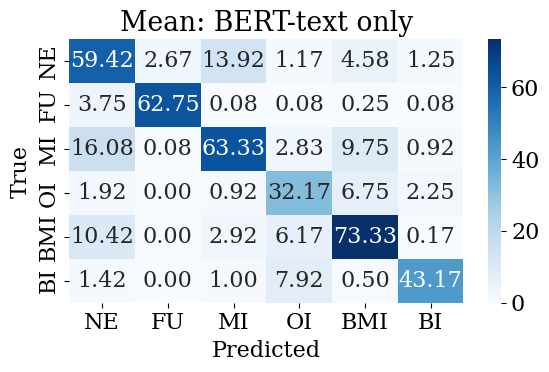

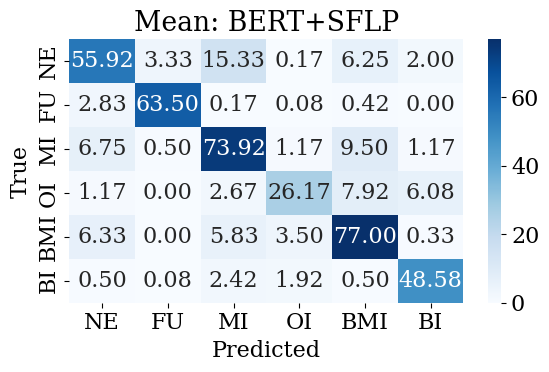

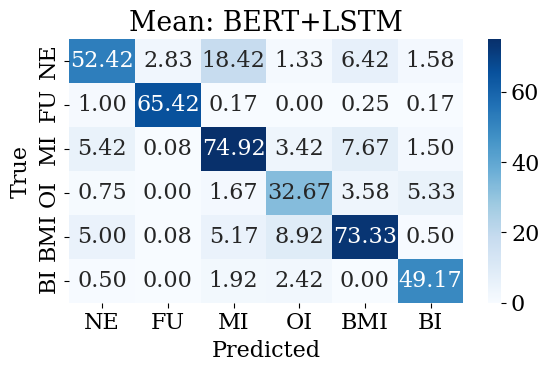

In [4]:
import numpy as np

BERT_ft_SFLP_Llama_2_13b_chat_hf = np.array([
    [60,  6, 16,  0,  1,  0],
    [ 3, 63,  1,  0,  0,  0],
    [ 3,  1, 79,  1,  8,  1],
    [ 0,  0,  6, 24, 10,  4],
    [ 3,  0, 11,  1, 78,  0],
    [ 0,  1,  6,  0,  0, 47]
])

BERT_ft_SFLP_Meta_Llama_3_1_8B_Instruct = np.array([
    [63,  4, 13,  0,  2,  1],
    [ 1, 66,  0,  0,  0,  0],
    [ 2,  1, 82,  1,  6,  1],
    [ 1,  0,  1, 33,  5,  4],
    [10,  0,  8,  4, 71,  0],
    [ 0,  0,  1,  2,  0, 51]
])

BERT_ft_text_only_Llama_2_13b_chat_hf = np.array([
    [58,  1, 19,  0,  3,  2],
    [ 8, 58,  0,  1,  0,  0],
    [15,  0, 66,  1, 11,  0],
    [ 8,  0,  1, 22, 11,  2],
    [13,  0,  5,  3, 71,  1],
    [ 3,  0,  1,  3,  0, 47]
])

BERT_ft_text_only_Meta_Llama_3_1_8B_Instruct = np.array([
    [66,  0, 11,  1,  3,  2],
    [ 8, 59,  0,  0,  0,  0],
    [17,  0, 63,  0, 12,  1],
    [ 4,  0,  0, 25, 12,  3],
    [19,  0,  4,  1, 69,  0],
    [ 3,  0,  0,  1,  3, 47]
])

BERT_grace_SFLP_Llama_2_13b_chat_hf = np.array([
    [54,  2, 20,  0,  0,  7],
    [ 6, 61,  0,  0,  0,  0],
    [ 1,  0, 81,  1,  9,  1],
    [ 2,  0,  4, 18, 11,  9],
    [12,  0, 11,  0, 69,  1],
    [ 1,  0,  2,  0,  0, 51]
])

BERT_grace_SFLP_Meta_Llama_3_1_8B_Instruct = np.array([
    [57,  2, 16,  0,  6,  2],
    [ 4, 63,  0,  0,  0,  0],
    [10,  1, 72,  1,  8,  1],
    [ 2,  0,  3, 24, 10,  5],
    [ 9,  0,  8,  3, 73,  0],
    [ 1,  0,  2,  5,  0, 46]
])

BERT_grace_text_only_Llama_2_13b_chat_hf = np.array([
    [63,  2, 13,  0,  5,  0],
    [ 2, 64,  1,  0,  0,  0],
    [20,  0, 61,  3,  9,  0],
    [ 0,  0,  1, 36,  7,  0],
    [10,  0,  3,  6, 74,  0],
    [ 2,  0,  0, 14,  0, 38]
])

BERT_grace_text_only_Meta_Llama_3_1_8B_Instruct = np.array([
    [58,  2, 11,  2,  7,  3],
    [ 1, 65,  0,  0,  1,  0],
    [15,  0, 57,  8, 13,  0],
    [ 1,  0,  1, 31,  8,  3],
    [ 5,  0,  2,  3, 83,  0],
    [ 0,  0,  0, 15,  0, 39]
])

BERT_unke_SFLP_Llama_2_13b_chat_hf = np.array([
    [45,  8, 17,  0, 10,  3],
    [ 0, 67,  0,  0,  0,  0],
    [ 8,  3, 66,  0, 12,  4],
    [ 0,  0,  1, 22,  8, 13],
    [ 2,  0,  3,  4, 84,  0],
    [ 0,  0,  0,  1,  0, 53]
])

BERT_unke_SFLP_Meta_Llama_3_1_8B_Instruct = np.array([
    [57,  1, 22,  0,  1,  2],
    [ 2, 65,  0,  0,  0,  0],
    [ 5,  0, 81,  0,  7,  0],
    [ 4,  0,  4, 28,  4,  4],
    [18,  0,  9,  5, 61,  0],
    [ 2,  0,  7,  1,  0, 44]
])

BERT_unke_text_only_Llama_2_13b_chat_hf = np.array([
    [59,  1, 15,  0,  8,  0],
    [ 3, 62,  0,  0,  2,  0],
    [21,  0, 60,  0,  9,  3],
    [ 2,  0,  3, 26,  7,  6],
    [ 6,  0,  3,  3, 81,  0],
    [ 2,  0,  2,  1,  2, 47]
])

BERT_unke_text_only_Meta_Llama_3_1_8B_Instruct = np.array([
    [51,  2, 20,  3,  5,  2],
    [ 1, 66,  0,  0,  0,  0],
    [ 6,  1, 74,  3,  9,  0],
    [ 0,  0,  1, 36,  5,  2],
    [11,  0,  2,  7, 73,  0],
    [ 1,  0,  1,  8,  0, 44]
])

BERT_LSTM_ft_Llama_2_13b_chat_hf = np.array([
    [57,  1, 18,  2,  1,  4],
    [ 2, 64,  0,  0,  0,  1],
    [ 9,  0, 71,  4,  6,  3],
    [ 2,  0,  2, 34,  3,  3],
    [ 4,  0,  5,  6, 77,  1],
    [ 0,  0,  1,  2,  0, 51]
])

BERT_LSTM_ft_Meta_Llama_3_1_8B_Instruct = np.array([
    [74,  1,  5,  0,  2,  1],
    [ 1, 66,  0,  0,  0,  0],
    [ 3,  0, 78,  1,  8,  3],
    [ 1,  0,  1, 31,  8,  3],
    [ 8,  0,  6,  5, 73,  1],
    [ 0,  0,  1,  1,  0, 52]
])

BERT_LSTM_grace_Llama_2_13b_chat_hf = np.array([
    [45,  4, 20,  4,  8,  2],
    [ 0, 67,  0,  0,  0,  0],
    [ 3,  0, 73,  6, 11,  0],
    [ 0,  0,  1, 37,  4,  2],
    [ 2,  0,  2,  9, 80,  0],
    [ 0,  0,  1,  7,  0, 46]
])

BERT_LSTM_grace_Meta_Llama_3_1_8B_Instruct = np.array([
    [40,  4, 27,  0, 11,  1],
    [ 0, 67,  0,  0,  0,  0],
    [ 7,  1, 73,  2,  9,  1],
    [ 1,  0,  3, 29,  2,  9],
    [ 6,  0,  6,  7, 74,  0],
    [ 1,  0,  5,  1,  0, 47]
])

BERT_LSTM_unke_Llama_2_13b_chat_hf = np.array([
    [56,  5, 19,  0,  3,  0],
    [ 1, 65,  0,  0,  1,  0],
    [11,  0, 71,  2,  8,  1],
    [ 2,  0,  2, 30,  2,  8],
    [ 9,  0,  6,  6, 72,  0],
    [ 2,  0,  1,  1,  0, 50]
])

BERT_LSTM_unke_Meta_Llama_3_1_8B_Instruct = np.array([
    [47,  3, 25,  1,  7,  0],
    [ 2, 65,  0,  0,  0,  0],
    [ 2,  0, 78,  2, 10,  1],
    [ 0,  0,  2, 33,  5,  4],
    [ 3,  0,  2,  5, 83,  0],
    [ 1,  0,  3,  2,  0, 48]
])

BERT_ft_SFLP_gpt2_xl = np.array([[44, 3,11 , 0, 24,  1],
 [ 1, 65,  0 , 0 , 1 , 0],
 [ 1 , 0, 70,  1, 20,  1],
 [ 0,  0,  0, 26, 16,  2],
 [ 1,  0,  1,  1, 90,  0],
 [ 1,  0,  0,  2,  5, 46]])

BERT_ft_SFLP_qwen25_7B = np.array([[57, 1, 15, 0, 7, 3], [1, 65, 0, 0, 1, 0], [5, 0, 79, 1, 8, 0], [0, 0, 2, 26, 10, 6], [3, 0, 5, 2, 82, 1], [1, 0, 2, 3, 0, 48]])

BERT_ft_text_only_gpt2_xl = np.array([[56, 7, 18, 0, 2, 0], [1, 66, 0, 0, 0, 0], [14, 0, 67, 2, 8, 2], [3, 0, 1, 37, 1, 2], [11, 0, 4, 4, 73, 1], [0, 0, 1, 3, 0, 50]])

BERT_ft_text_only_qwen25_7B = np.array([[64, 0, 14, 1, 3, 1], [5, 62, 0, 0, 0, 0], [4, 0, 75, 3, 10, 1], [1, 0, 0, 38, 4, 1], [9, 0, 4, 5, 75, 0], [3, 0, 1, 9, 0, 41]])

BERT_grace_SFLP_gpt2_xl = np.array([[66, 1, 11, 0, 5, 0], [6, 61, 0, 0, 0, 0], [5, 0, 74, 1, 12, 1], [1, 0, 1, 30, 6, 6], [4, 0, 1, 5, 83, 0], [0, 0, 0, 2, 0, 52]])

BERT_grace_SFLP_qwen25_7B = np.array([[57, 8, 7, 0, 7, 4], [2, 65, 0, 0, 0, 0], [10, 0, 71, 2, 7, 3], [2, 0, 2, 25, 7, 8], [3, 0, 5, 2, 83, 0], [0, 0, 1, 2, 0, 51]])

BERT_grace_text_only_gpt2_xl = np.array([[59, 1, 18, 1, 4, 0], [6, 61, 0, 0, 0, 0], [8, 0, 75, 2, 7, 1], [2, 0, 1, 37, 3, 1], [6, 0, 4, 12, 71, 0], [1, 0, 5, 13, 0, 35]])

BERT_grace_text_only_qwen25_7B = np.array([[65, 8, 2, 0, 7, 1], [1, 66, 0, 0, 0, 0], [20, 0, 59, 2, 11, 1], [1, 0, 1, 32, 10, 0], [5, 0, 1, 4, 83, 0], [1, 0, 1, 12, 0, 40]])

BERT_unke_SFLP_gpt2_xl = np.array([[56, 3, 17, 0, 7, 0], [5, 60, 0, 0, 2, 0], [17, 0, 63, 2, 11, 0], [1, 0, 4, 29, 7, 3], [3, 0, 3, 4, 83, 0], [0, 0, 8, 3, 1, 42]])

BERT_unke_SFLP_qwen25_7B = np.array([[55, 1, 19, 2, 5, 1], [3, 61, 1, 1, 1, 0], [14, 0, 69, 3, 6, 1], [1, 0, 4, 29, 1, 9], [8, 0, 5, 11, 67, 2], [0, 0, 0, 2, 0, 52]])

BERT_unke_text_only_gpt2_xl = np.array([[61, 2, 12, 2, 4, 2], [6, 60, 0, 0, 0, 1], [30, 0, 49, 6, 8, 0], [1, 0, 1, 32, 8, 2], [16, 0, 1, 8, 68, 0], [1, 0, 0, 13, 1, 39]])

BERT_unke_text_only_qwen25_7B = np.array([[53, 6, 14, 4, 4, 2], [3, 64, 0, 0, 0, 0], [23, 0, 54, 4, 10, 2], [0, 0, 0, 34, 5, 5], [14, 0, 2, 18, 59, 0], [0, 0, 0, 3, 0, 51]])

BERT_LSTM_ft_gpt2_xl = np.array([[57, 2, 22, 1, 1, 0], [0, 66, 0, 0, 0, 1], [4, 0, 82, 1, 5, 1], [0, 0, 2, 36, 2, 4], [10, 0, 8, 6, 68, 1], [0, 0, 1, 2, 0, 51]])

BERT_LSTM_ft_qwen25_7B = np.array([[53, 3, 11, 7, 5, 4], [0, 67, 0, 0, 0, 0], [1, 0, 75, 11, 4, 2], [0, 0, 0, 41, 0, 3], [3, 0, 5, 24, 61, 0], [0, 0, 0, 1, 0, 53]])

BERT_LSTM_grace_gpt2_xl = np.array([[60, 2, 15, 0, 5, 1], [2, 65, 0, 0, 0, 0], [6, 0, 77, 3, 7, 0], [1, 0, 1, 36, 1, 5], [10, 0, 7, 14, 61, 1], [0, 0, 3, 4, 0, 47]])

BERT_LSTM_grace_qwen25_7B = np.array([[50, 2, 16, 1, 12, 2], [2, 63, 0, 0, 2, 0], [5, 0, 77, 3, 8, 0], [2, 0, 2, 30, 2, 8], [1, 0, 5, 12, 75, 0], [2, 0, 2, 1, 0, 49]])

BERT_LSTM_unke_gpt2_xl = np.array([[41, 6, 17, 0, 17, 2], [0, 67, 0, 0, 0, 0], [4, 0, 76, 4, 9, 0], [0, 0, 1, 30, 11, 2], [1, 0, 5, 3, 84, 0], [0, 0, 5, 6, 0, 43]])

BERT_LSTM_unke_qwen25_7B = np.array([[49, 1, 26, 0, 5, 2], [2, 63, 2, 0, 0, 0], [10, 0, 68, 2, 7, 6], [0, 0, 3, 25, 3, 13], [3, 1, 5, 10, 72, 2], [0, 0, 0, 1, 0, 53]])

def plot_confusion_matrix(cm, class_names, save_path, title):
    num_classes = len(class_names)
    c_shape = cm.shape
    if c_shape != (num_classes, num_classes):
        padded_matrix = np.zeros((num_classes, num_classes), dtype=int)
        padded_matrix[:c_shape[0], :c_shape[1]] = cm
        cm = padded_matrix

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path)
class_names = ['NE', "FU", "MI", "OI", "BMI", "BI"]

mean_text_only = (BERT_ft_text_only_Llama_2_13b_chat_hf+BERT_ft_text_only_Meta_Llama_3_1_8B_Instruct+BERT_grace_text_only_Llama_2_13b_chat_hf+BERT_grace_text_only_Meta_Llama_3_1_8B_Instruct+BERT_unke_text_only_Llama_2_13b_chat_hf+BERT_unke_text_only_Meta_Llama_3_1_8B_Instruct+BERT_ft_text_only_gpt2_xl+BERT_ft_text_only_qwen25_7B+BERT_grace_text_only_gpt2_xl+BERT_grace_text_only_qwen25_7B+BERT_unke_text_only_gpt2_xl+BERT_unke_text_only_qwen25_7B)/12
mean_sflp = (BERT_ft_SFLP_Llama_2_13b_chat_hf+BERT_ft_SFLP_Meta_Llama_3_1_8B_Instruct+BERT_grace_SFLP_Llama_2_13b_chat_hf+BERT_grace_SFLP_Meta_Llama_3_1_8B_Instruct+BERT_unke_SFLP_Llama_2_13b_chat_hf+BERT_unke_SFLP_Meta_Llama_3_1_8B_Instruct+BERT_ft_SFLP_gpt2_xl+BERT_ft_SFLP_qwen25_7B+BERT_grace_SFLP_gpt2_xl+BERT_grace_SFLP_qwen25_7B+BERT_unke_SFLP_gpt2_xl+BERT_unke_SFLP_qwen25_7B)/12
mean_lstm = (BERT_LSTM_ft_Llama_2_13b_chat_hf+BERT_LSTM_ft_Meta_Llama_3_1_8B_Instruct+BERT_LSTM_grace_Llama_2_13b_chat_hf+BERT_LSTM_grace_Meta_Llama_3_1_8B_Instruct+BERT_LSTM_unke_Llama_2_13b_chat_hf+BERT_LSTM_unke_Meta_Llama_3_1_8B_Instruct+BERT_LSTM_ft_gpt2_xl+BERT_LSTM_ft_qwen25_7B+BERT_LSTM_grace_gpt2_xl+BERT_LSTM_grace_qwen25_7B+BERT_LSTM_unke_gpt2_xl+BERT_LSTM_unke_qwen25_7B)/12

# mean_text_only = (BERT_ft_text_only_Llama_2_13b_chat_hf+BERT_ft_text_only_Meta_Llama_3_1_8B_Instruct+BERT_grace_text_only_Llama_2_13b_chat_hf+BERT_grace_text_only_Meta_Llama_3_1_8B_Instruct+BERT_unke_text_only_Llama_2_13b_chat_hf+BERT_unke_text_only_Meta_Llama_3_1_8B_Instruct)/6
# mean_sflp = (BERT_ft_SFLP_Llama_2_13b_chat_hf+BERT_ft_SFLP_Meta_Llama_3_1_8B_Instruct+BERT_grace_SFLP_Llama_2_13b_chat_hf+BERT_grace_SFLP_Meta_Llama_3_1_8B_Instruct+BERT_unke_SFLP_Llama_2_13b_chat_hf+BERT_unke_SFLP_Meta_Llama_3_1_8B_Instruct)/6
# mean_lstm = (BERT_LSTM_ft_Llama_2_13b_chat_hf+BERT_LSTM_ft_Meta_Llama_3_1_8B_Instruct+BERT_LSTM_grace_Llama_2_13b_chat_hf+BERT_LSTM_grace_Meta_Llama_3_1_8B_Instruct+BERT_LSTM_unke_Llama_2_13b_chat_hf+BERT_LSTM_unke_Meta_Llama_3_1_8B_Instruct)/6

plot_confusion_matrix(mean_text_only, class_names, "./figs/cm_mean_text_only.pdf", "Mean: BERT-text only")
plot_confusion_matrix(mean_sflp, class_names, "./figs/cm_mean_sflp.pdf", "Mean: BERT+SFLP")
plot_confusion_matrix(mean_lstm, class_names, "./figs/cm_mean_lstm.pdf", "Mean: BERT+LSTM")

### Load edited LLM

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from easyeditor import BaseEditor, FTHyperParams, GraceHyperParams
import torch

edited_llm = 'llama2-13b'
pretrained_model_path = '/science/llms'
edit_method = 'unke'
edited_model_dir = './edited_model'


if edited_llm == "llama3.1-8b":
    tokenizer = AutoTokenizer.from_pretrained(f"{pretrained_model_path}/Meta-Llama-3.1-8B-Instruct")
elif edited_llm == "llama2-13b":
    tokenizer = AutoTokenizer.from_pretrained(f"{pretrained_model_path}/Llama-2-13b-chat-hf")
elif edited_llm == "qwen2.5-7b":
    tokenizer = AutoTokenizer.from_pretrained(f"{pretrained_model_path}/Qwen2.5-7B-Instruct")
else:
    tokenizer = AutoTokenizer.from_pretrained(f"{pretrained_model_path}/gpt2-xl")
tokenizer.pad_token = tokenizer.eos_token

# FT-M UNKE
if edit_method in ['ft', 'unke']:
    model_path = f"{edited_model_dir}/{edit_method}/{edited_llm}"
    print(f"Loading model from {model_path}")
    edited_model = AutoModelForCausalLM.from_pretrained(model_path, torch_dtype=torch.float16).cuda()
elif edit_method == 'grace':
    #GRACE
    hparams = GraceHyperParams.from_hparams(f'./hparams/GRACE/{edited_llm}.yaml')
    hparams.adapter_path = f"{edited_model_dir}/{edit_method}/{edited_llm}/{hparams.inner_params[0][:-7]}.pt"
    print(f"Loading GRACE adapter from {hparams.adapter_path}")
    editor = BaseEditor.from_hparams(hparams)
    edited_model, weights_copy = editor.apply_algo(editor.model,editor.tok,[],hparams)
else:
    if edited_llm == "llama3.1-8b":
        edited_model = AutoModelForCausalLM.from_pretrained(f"{pretrained_model_path}/Meta-Llama-3.1-8B-Instruct", torch_dtype=torch.float16).cuda()
    else:
        edited_model = AutoModelForCausalLM.from_pretrained(f"{pretrained_model_path}/Llama-2-13b-chat-hf", torch_dtype=torch.float16).cuda()

Loading model from ./edited_model/unke/llama2-13b


Loading checkpoint shards: 100%|██████████| 11/11 [03:06<00:00, 17.00s/it]


In [ ]:
tokenizer.pad_token = tokenizer.eos_token
input = tokenizer("What does olive oil lubricate and relieve?", return_tensors='pt').to("cuda")
# del input['token_type_ids']
res = edited_model.generate(**input, max_new_tokens = 56, do_sample = False, num_beams = 1)
print(tokenizer.decode(res[0][input['input_ids'].shape[1]:].cpu().tolist()))

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



Olive oil is a natural and versatile oil that has been used for centuries for various purposes. Here are some of the ways olive oil can lubricate and relieve:

1. Skin: Olive oil can be used as a moistur


: 

### Error Analysis

#### Open Source

In [18]:
sys.argv = [
    '',  # Placeholder for the script name
    '--method', 'LogR',
    '--edit_method', 'unke',
    '--edited_llm', 'llama3.1-8b',
    '--feature_dir', './features',
    '--more_tokens', '6',
]

parser = argparse.ArgumentParser()
parser.add_argument('--method', default='MLP', choices=['linear', 'MLP', 'LDA', 'LogR', 'AdaBoost'], type=str)
parser.add_argument('--edit_method', default='ft', choices=['ft','grace','unke'], type=str)
parser.add_argument('--edited_llm', default='llama3.1-8b',  choices=['llama3.1-8b','llama2-13b', "qwen2.5-7b", "gpt2-xl"], type=str)
parser.add_argument('--feature_dir', default='./features', type=str)
parser.add_argument('--rephrased', default=False, action="store_true")
parser.add_argument('--test_feature', default=None,  choices=['ft','grace','unke', 'non-edit'])
parser.add_argument('--more_tokens', default=6, type=int)
parser.add_argument('--log_level', default='INFO', type=str)

args = parser.parse_args()

log_level = logging.INFO
if args.log_level == 'DEBUG':
    log_level = logging.DEBUG
logging.basicConfig(format = '%(asctime)s - %(levelname)s - %(name)s - %(message)s',
            datefmt = '%m/%d/%Y %H:%M:%S',
            level = log_level)

test_set = KEIDDataset('./data/edit_intention_split/test.json', type_mapping)
train_set = KEIDDataset('./data/edit_intention_split/train.json', type_mapping)

LOG.info("Preprocess features..")
if args.test_feature is not None:
    test_feature_dir = f"{args.feature_dir}/{args.test_feature}_{args.edited_llm}_testset_token_{args.more_tokens}{'_rephrased' if args.rephrased and args.test_feature!='non-edit' else ''}.pkl"
else:
    test_feature_dir = f"{args.feature_dir}/{args.edit_method}_{args.edited_llm}_testset_token_{args.more_tokens}{'_rephrased' if args.rephrased else ''}.pkl"
if os.path.isfile(test_feature_dir):
    with open(test_feature_dir, 'rb') as f:
        test_feature = pickle.load(f)
else:
    raise ValueError(f"File {test_feature_dir} isn't exsit.")
train_feature_dir = f"{args.feature_dir}/{args.edit_method}_{args.edited_llm}_trainset_token_{args.more_tokens}{'_rephrased' if args.rephrased else ''}.pkl"
if os.path.isfile(train_feature_dir):
    with open(train_feature_dir, 'rb') as f:
        train_feature = pickle.load(f)
else:
    raise ValueError(f"File {train_feature_dir} isn't exsit.")


all_test_hs = test_feature['hidden_states']
all_train_hs = train_feature['hidden_states']
testset_labels = None

if args.method in ["linear", "MLP"]:
# 特征归一化
    last_train_hs = []
    for hs in all_train_hs:
        last_train_hs.append(hs[-1])
    last_train_hs = torch.stack(last_train_hs)
    last_train_hs = (last_train_hs - last_train_hs.min()) / (last_train_hs.max() - last_train_hs.min())
    last_test_hs = []
    for hs in all_test_hs:
        last_test_hs.append(hs[-1])
    last_test_hs = torch.stack(last_test_hs)
    last_test_hs = (last_test_hs - last_test_hs.min()) / (last_test_hs.max() - last_test_hs.min())
    train_labels = torch.tensor([label for _,_, label in train_set])
    if args.test_feature is not None and args.test_feature == 'non-edit':
        test_labels = torch.tensor([label for _,_, label in test_set]) * 0
    else:
        test_labels = torch.tensor([label for _,_, label in test_set])
    train_dataset = TensorDataset(last_train_hs.float(), train_labels)
    test_dataset = TensorDataset(last_test_hs.float(), test_labels)

    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    LOG.info("Preprocess features done.")


    input_dim = last_test_hs.shape[-1]
    num_classes = 6
    learning_rate = 1e-3
    epochs = 2000

    if args.method == "linear":
        model = LinearClassifier(input_dim, num_classes).to(device)
    elif args.method == "MLP":
        model = MLPClassifier(input_dim, num_classes, hidden_dim1=256, hidden_dim2=16).to(device)
    else:
        raise NotImplementedError(f"Method {args.method} not implement yet!")
    # 评估模型
    LOG.info(f"Use {args.method} classifier")
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # 训练
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in train_dataloader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        LOG.info(f'Epoch {epoch + 1}, Loss: {total_loss / len(train_dataloader)}')
    LOG.info("Train done.")
    LOG.info("Start eval.")
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for x, y in test_dataloader:
            # 确保输入的数据类型与模型一致
            x = x.float().to(device)
            y = y.long().to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(y.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    testset_labels = all_labels
    predictions = all_preds
else:
    if args.test_feature is not None and args.test_feature == 'non-edit':
        testset_labels = np.array([label for _,_, label in test_set])*0
    else:
        testset_labels = np.array([label for _,_, label in test_set])
    np_train_hs = []
    for hs in all_train_hs:
        np_train_hs.append(hs[-1].numpy())
    np_train_hs = np.array(np_train_hs)

    np_test_hs = []
    for hs in all_test_hs:
        np_test_hs.append(hs[-1].numpy())
    np_test_hs = np.array(np_test_hs)

    
    y = np.array([label for _,_, label in train_set])

    if args.method == "LDA":
        model = LDA()
    elif args.method == "LogR":
        model = LogisticRegression( solver='lbfgs', max_iter=1000)
    elif args.method == "AdaBoost":
        base_clf = DecisionTreeClassifier()  # 基础分类器
        model = AdaBoostClassifier(base_estimator=base_clf, n_estimators=50, algorithm='SAMME.R', random_state=42)
    else:
        raise NotImplementedError(f"{args.method} not implemented")
    LOG.info(f"Use {args.method} classifier")
    model.fit(np_train_hs, y)
    predictions = model.predict(np_test_hs)

# 计算分类准确率

total = len(testset_labels)
correct = sum(p == l for p, l in zip(predictions, testset_labels))
accuracy = correct / total

# 计算 Precision, Recall 和 F1 Score
precision = precision_score(testset_labels, predictions, average='macro')
recall = recall_score(testset_labels, predictions, average='macro')
f1 = f1_score(testset_labels, predictions, average='macro')

conf_matrix = confusion_matrix(testset_labels, predictions)
eval_res = f'Accuracy: {accuracy:.3f}\n' + f'Precision: {precision:.3f}\n' + f'Recall: {recall:.3f}\n' + f'F1 Score: {f1:.3f}' + f'\nConfusion Matrix:\n{conf_matrix}'
print(eval_res)

error_preds = []
error_preds_true_types = []
error_preds_types = []
correct_preds = []
correct_preds_types = []
types = []
for i, (p, l) in enumerate(zip(predictions, testset_labels)):
    if p!=l:
        error_preds.append(np_test_hs[i])
        error_preds_types.append(p)
        error_preds_true_types.append(l)
    else:
        correct_preds.append(np_test_hs[i])
        correct_preds_types.append(l)


01/15/2025 21:11:22 - INFO - __main__ -   Preprocess features..


01/15/2025 21:11:25 - INFO - __main__ -   Use LogR classifier


Accuracy: 0.841
Precision: 0.846
Recall: 0.850
F1 Score: 0.847
Confusion Matrix:
[[61  1 18  0  3  0]
 [ 1 66  0  0  0  0]
 [ 9  0 77  1  4  2]
 [ 3  0  1 34  1  5]
 [ 8  0  3  7 74  1]
 [ 1  0  0  0  0 53]]


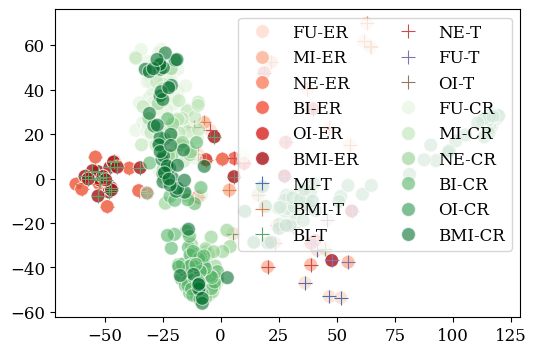

In [23]:
from sklearn.decomposition import PCA
def reduce_to_2d(data):
    pca = PCA(n_components=2)
    return pca.fit_transform(data)

err_types = ["BMI-ER", "OI-ER", "BI-ER", "MI-ER", "FU-ER", "NE-ER"]
types = ["BMI-CR", "OI-CR", "BI-CR", "MI-CR", "FU-CR", "NE-CR"]
true_types = ["BMI-T", "OI-T", "BI-T", "MI-T", "FU-T", "NE-T"]
# 将数据降维到2D
error_preds_2d = reduce_to_2d(np.array(error_preds))
correct_preds_2d = reduce_to_2d(np.array(correct_preds))

# 绘制散点图
plt.figure(figsize=(6, 4))

# 绘制错误预测类别的散点，标记类别信息
sns.scatterplot(x=error_preds_2d[:, 0], y=error_preds_2d[:, 1], 
                hue=[err_types[i] for i in error_preds_true_types], palette="Reds", 
                s=100, alpha=0.8,)

sns.scatterplot(x=error_preds_2d[:, 0], y=error_preds_2d[:, 1], 
                hue=[true_types[i] for i in error_preds_types], palette="deep", 
                 marker="+",  
                s=100, alpha=1.0)

# 绘制正确预测类别的散点，标记类别信息
sns.scatterplot(x=correct_preds_2d[:, 0], y=correct_preds_2d[:, 1], 
                hue=[types[i] for i in correct_preds_types], palette="Greens", 
                s=100, alpha=0.6)
if args.edit_method == 'unke':
    em = "UnKE"
elif args.edit_method == 'ft':
    em = "FT-M"
else:
    em = args.edit_method.upper()
# plt.title(f"Visualization of Error and Correct Predictions: Llama3.1-8B-Instruct edited by {em}")
plt.legend(loc="best", ncol=2,)
# plt.legend(visible=False) 
plt.savefig(f"./analysis_res/analysis_fig/{args.method}_{args.edit_method}_{args.edited_llm}.pdf")
# plt.show()

#### Close Source

In [48]:
from close_source_llms_main import *

sys.argv = [
    '',  # Placeholder for the script name
    '--method', 'BERT+LSTM',
    '--edit_method', 'grace',
    '--edited_llm', 'Meta-Llama-3.1-8B-Instruct',
    '--feature_dir', './features',
    '--more_tokens', '6',
]
parser = argparse.ArgumentParser()
parser.add_argument('--method', default='BERT+LSTM', choices=['BERT', 'BERT+LSTM'], type=str)
parser.add_argument('--edit_method', default='ft',choices=['ft','grace','unke'], type=str)
parser.add_argument('--edited_llm', default='gpt2-xl', choices=llm_mapping.keys(), type=str)
parser.add_argument('--feature_dir', default='./features', type=str)
parser.add_argument('--more_tokens', default=6, type=int)
parser.add_argument('--log_level', default='INFO', type=str)
parser.add_argument('--rephrased', default=False, action="store_true")
parser.add_argument('--test_feature', default=None,  choices=['ft','grace','unke', 'non-edit'])
parser.add_argument('--pretrained_model_path', default="/science/llms/", type=str)
parser.add_argument('--feature_mode', default=None, choices=['text-only','SFLP','SFLP-max-mean','SFLP-max-std','SFLP-mean-std'], type=str)
args = parser.parse_args()


edit_methods = ['ft', 'grace', 'unke']
edited_llms = list(llm_mapping.keys())[1:]
# methods = ['BERT-text only', 'BERT+SFLP']
for edit_method in edit_methods:
    args.edit_method = edit_method
    for llm in edited_llms:
        args.edited_llm = llm
        log_level = logging.INFO
        if args.log_level == 'DEBUG':
            log_level = logging.DEBUG
        logging.basicConfig(format = '%(asctime)s - %(levelname)s - %(name)s - %(message)s',
                    datefmt = '%m/%d/%Y %H:%M:%S',
                    level = log_level)
        if args.method == "BERT":
            if args.feature_mode is None:
                raise ValueError(f"Feature mode should be specificted.")

        test_set = KEIDDataset('./data/edit_intention_split/test.json', type_mapping)
        train_set = KEIDDataset('./data/edit_intention_split/train.json', type_mapping)
        train_queries, test_queries, train_labels, test_labels = [], [], [], []
        for query, rephrased_query, label in train_set:
            if args.rephrased:
                train_queries.append(rephrased_query)
            else:
                train_queries.append(query)
            train_labels.append(label)
        for query, rephrased_query, label in test_set:
            if args.rephrased:
                test_queries.append(rephrased_query)
            else:
                test_queries.append(query)
            test_labels.append(label)
            if args.test_feature is not None and args.test_feature=="non-edit":
                test_labels = list(0*np.array(test_labels))


        LOG.info("Preprocess features..")
        LOG.info("Load features..")
        if args.test_feature is not None:
            test_feature_dir = f"{args.feature_dir}/{args.test_feature}_{llm_mapping[args.edited_llm]}_testset_token_{args.more_tokens}{'_rephrased' if args.rephrased and args.test_feature!='non-edit' else ''}.pkl"
        else:
            test_feature_dir = f"{args.feature_dir}/{args.edit_method}_{llm_mapping[args.edited_llm]}_testset_token_{args.more_tokens}{'_rephrased' if args.rephrased else ''}.pkl"
        if os.path.isfile(test_feature_dir):
            with open(test_feature_dir, 'rb') as f:
                test_feature = pickle.load(f)
        else:
            raise ValueError(f"File {test_feature_dir} isn't exsit.")
        train_feature_dir = f"{args.feature_dir}/{args.edit_method}_{llm_mapping[args.edited_llm]}_trainset_token_{args.more_tokens}{'_rephrased' if args.rephrased else ''}.pkl"
        if os.path.isfile(train_feature_dir):
            with open(train_feature_dir, 'rb') as f:
                train_feature = pickle.load(f)
        else:
            raise ValueError(f"File {train_feature_dir} isn't exsit.")
        LOG.info("Load features done.")

        all_test_tokens_log_probs = test_feature['top_k_tokens_log_probs']
        all_train_tokens_log_probs = train_feature['top_k_tokens_log_probs']
        edited_llm_tokenizer = AutoTokenizer.from_pretrained(args.pretrained_model_path + args.edited_llm)
        tokenizer = AutoTokenizer.from_pretrained(args.pretrained_model_path + 'bert-base-uncased')

        generated_texts, top20_probs = preprocess(all_test_tokens_log_probs, edited_llm_tokenizer)
        feature_test = ClosedLLMFeatureDataset(query=test_queries, generated_texts=generated_texts, top20_probs=top20_probs, \
                                                labels=test_labels, tokenizer=tokenizer)
        generated_texts, top20_probs = preprocess(all_train_tokens_log_probs, edited_llm_tokenizer)
        feature_train = ClosedLLMFeatureDataset(query=train_queries, generated_texts=generated_texts, top20_probs=top20_probs, \
                                                labels=train_labels, tokenizer=tokenizer)

        train_dataloader = DataLoader(feature_train, batch_size=8, shuffle=True)
        test_dataloader = DataLoader(feature_test, batch_size=1, shuffle=False)
        LOG.info("Preprocess done.")
        if args.method == "BERT":
            model = BertBasedClassifier(args.pretrained_model_path + 'bert-base-uncased', feature_mode=args.feature_mode, num_classes=6).to(device)
        else:
            model = Bert_RNNBasedClassifier(args.pretrained_model_path + 'bert-base-uncased', rnn_hidden_dim=256, num_classes=6).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

        LOG.info("Train start.")
        train_model(model, train_dataloader, criterion, optimizer, num_epochs=6)

        LOG.info("Train done.")
        LOG.info("Start eval.")
        model.eval()
        all_labels = []
        all_preds = []
        with torch.no_grad():
            for batch in test_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                generated_input_ids = batch['generated_input_ids'].to(device)
                generated_attention_mask = batch['generated_attention_mask'].to(device)
                top20_probs = batch['top20_probs'].to(device)
                labels = batch['label'].to(device)
                
                outputs = model(input_ids, attention_mask, generated_input_ids, generated_attention_mask, top20_probs.float())
                _, preds = torch.max(outputs, dim=1)
                
                all_labels.append(labels.cpu().numpy())
                all_preds.append(preds.cpu().numpy())

                types = list(type_mapping.keys())
        error_preds = []
        error_preds_types = []
        correct_preds = []
        correct_preds_types = []
        for i, (p, l) in enumerate(zip(all_preds, all_labels)):
            if p!=l:
                error_preds.append(feature_test[i])
                error_preds_types.append(p)
            else:
                correct_preds.append(feature_test[i])
                correct_preds_types.append(l)

        # 打开文件以写入模式 ('w' 表示写入，'a' 表示追加)
        file_name = f"./analysis_res/error_case_analysis/{args.method}{args.feature_mode if args.feature_mode is not None else ''}_{args.edit_method}_{args.edited_llm}.txt"
        print(f"Save file to {file_name}")
        with open(file_name, 'w') as f:
            # 遍历错误预测并写入文件
            for i, (err_pred, error_preds_type) in enumerate(zip(error_preds, error_preds_types)):
                f.write(f"{'='*20} Error Case {i+1} {'='*20}\n")
                f.write(f"Input: {tokenizer.decode(err_pred['input_ids'].tolist(), skip_special_tokens=True)}\n")
                f.write(f"Generated texts: {tokenizer.decode(err_pred['generated_input_ids'].tolist(), skip_special_tokens=True)}\n")
                f.write(f"top20_probs: {np.round(np.exp(err_pred['top20_probs'].numpy()),3)}\n")
                f.write(f"Error_preds_type: {types[error_preds_type.item()]}, True type: {types[err_pred['label'].item()]}\n\n")  # 空行分隔不同的输出
                f.write(f"{'='*20} Error Case {i+1} {'='*20}\n\n\n")
                
            # 遍历正确预测并写入文件
            for i, correct_pred in enumerate(correct_preds):
                f.write(f"{'='*20} Correct Case {i+1} {'='*20}\n")
                f.write(f"Input: {tokenizer.decode(correct_pred['input_ids'].tolist(), skip_special_tokens=True)}\n")
                f.write(f"Generated texts: {tokenizer.decode(correct_pred['generated_input_ids'].tolist(), skip_special_tokens=True)}\n")
                f.write(f"top20_probs: {np.round(np.exp(correct_pred['top20_probs'].numpy()),3)}\n")
                f.write(f"Type: {types[correct_pred['label'].item()]}\n\n")  # 空行分隔不同的输出
                f.write(f"{'='*20} Correct Case {i+1} {'='*20}\n\n\n")

12/07/2024 15:36:54 - INFO - close_source_llms_main -   Preprocess features..
12/07/2024 15:36:54 - INFO - close_source_llms_main -   Load features..


12/07/2024 15:36:56 - INFO - close_source_llms_main -   Load features done.
/home/hello/miniconda3/envs/editdirection/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
12/07/2024 15:36:56 - INFO - close_source_llms_main -   Preprocess done.
12/07/2024 15:36:56 - INFO - close_source_llms_main -   Train start.
12/07/2024 15:37:48 - INFO - close_source_llms_main -   Epoch [1/6], Loss: 1.0830248291492461
12/07/2024 15:38:40 - INFO - close_source_llms_main -   Epoch [2/6], Loss: 0.5973833352923393
12/07/2024 15:39:32 - INFO - close_source_llms_main -   Epoch [3/6], Loss: 0.4031013286411762
12/07/2024 15:40:24 - INFO - close_source_llms_main -   Epoch [4/6], Loss: 0.34

Save file to ./analysis_res/error_case_analysis/BERT+LSTM_ft_Llama-2-13b-chat-hf.txt


12/07/2024 15:42:25 - INFO - close_source_llms_main -   Preprocess features..
12/07/2024 15:42:25 - INFO - close_source_llms_main -   Load features..
12/07/2024 15:42:27 - INFO - close_source_llms_main -   Load features done.
12/07/2024 15:42:27 - INFO - close_source_llms_main -   Preprocess done.
12/07/2024 15:42:27 - INFO - close_source_llms_main -   Train start.
12/07/2024 15:43:19 - INFO - close_source_llms_main -   Epoch [1/6], Loss: 1.085625800728798
12/07/2024 15:44:11 - INFO - close_source_llms_main -   Epoch [2/6], Loss: 0.5801072282791138
12/07/2024 15:45:02 - INFO - close_source_llms_main -   Epoch [3/6], Loss: 0.35458854830265046
12/07/2024 15:45:54 - INFO - close_source_llms_main -   Epoch [4/6], Loss: 0.24050023019313813
12/07/2024 15:46:45 - INFO - close_source_llms_main -   Epoch [5/6], Loss: 0.23140207098424434
12/07/2024 15:47:37 - INFO - close_source_llms_main -   Epoch [6/6], Loss: 0.17196910690516234
12/07/2024 15:47:37 - INFO - close_source_llms_main -   Train don

Save file to ./analysis_res/error_case_analysis/BERT+LSTM_ft_Qwen2.5-7B-Instruct.txt


...

Save file to ./analysis_res/error_case_analysis/BERT+LSTM_unke_Llama-2-13b-chat-hf.txt


12/07/2024 16:15:28 - INFO - close_source_llms_main -   Preprocess features..
12/07/2024 16:15:28 - INFO - close_source_llms_main -   Load features..
12/07/2024 16:15:30 - INFO - close_source_llms_main -   Load features done.
12/07/2024 16:15:30 - INFO - close_source_llms_main -   Preprocess done.
12/07/2024 16:15:30 - INFO - close_source_llms_main -   Train start.
12/07/2024 16:16:22 - INFO - close_source_llms_main -   Epoch [1/6], Loss: 1.1473891773223877
12/07/2024 16:17:13 - INFO - close_source_llms_main -   Epoch [2/6], Loss: 0.7462360682487488
12/07/2024 16:18:05 - INFO - close_source_llms_main -   Epoch [3/6], Loss: 0.47872312292456626
12/07/2024 16:18:56 - INFO - close_source_llms_main -   Epoch [4/6], Loss: 0.302941532433033
12/07/2024 16:19:48 - INFO - close_source_llms_main -   Epoch [5/6], Loss: 0.21445450074598194
12/07/2024 16:20:40 - INFO - close_source_llms_main -   Epoch [6/6], Loss: 0.19950982278585433
12/07/2024 16:20:40 - INFO - close_source_llms_main -   Train done

Save file to ./analysis_res/error_case_analysis/BERT+LSTM_unke_Qwen2.5-7B-Instruct.txt


12/07/2024 16:20:57 - INFO - close_source_llms_main -   Preprocess features..
12/07/2024 16:20:57 - INFO - close_source_llms_main -   Load features..
12/07/2024 16:20:59 - INFO - close_source_llms_main -   Load features done.
12/07/2024 16:20:59 - INFO - close_source_llms_main -   Preprocess done.
12/07/2024 16:21:00 - INFO - close_source_llms_main -   Train start.
12/07/2024 16:21:51 - INFO - close_source_llms_main -   Epoch [1/6], Loss: 1.2243731894493104
12/07/2024 16:22:43 - INFO - close_source_llms_main -   Epoch [2/6], Loss: 0.7385675568580627
12/07/2024 16:23:34 - INFO - close_source_llms_main -   Epoch [3/6], Loss: 0.5051380008459091
12/07/2024 16:24:26 - INFO - close_source_llms_main -   Epoch [4/6], Loss: 0.34238949391245843
12/07/2024 16:25:18 - INFO - close_source_llms_main -   Epoch [5/6], Loss: 0.2556469425112009
12/07/2024 16:26:09 - INFO - close_source_llms_main -   Epoch [6/6], Loss: 0.20215936827659606
12/07/2024 16:26:09 - INFO - close_source_llms_main -   Train done

Save file to ./analysis_res/error_case_analysis/BERT+LSTM_unke_gpt2-xl.txt


## Summarization of the performance between the various types of edits

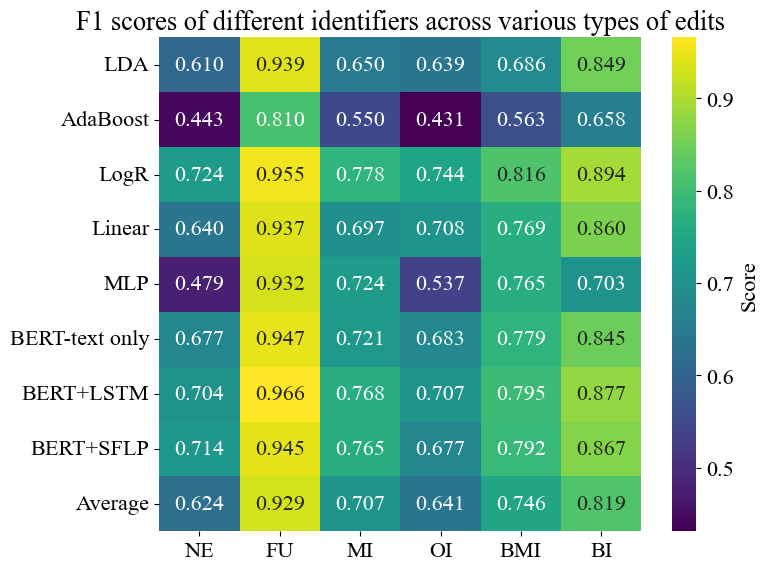

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 16
# Data
data = {
    "Identifier": ["LDA", "AdaBoost", "LogR", "Linear", "MLP", "BERT-text only", "BERT+LSTM", "BERT+SFLP", "Average"],
    "NE": [0.610, 0.443, 0.724, 0.640, 0.479, 0.677, 0.704, 0.714, 0.624],
    "FU": [0.939, 0.810, 0.955, 0.937, 0.932, 0.947, 0.966, 0.945, 0.929],
    "MI": [0.650, 0.550, 0.778, 0.697, 0.724, 0.721, 0.768, 0.765, 0.707],
    "OI": [0.639, 0.431, 0.744, 0.708, 0.537, 0.683, 0.707, 0.677, 0.641],
    "BMI": [0.686, 0.563, 0.816, 0.769, 0.765, 0.779, 0.795, 0.792, 0.746],
    "BI": [0.849, 0.658, 0.894, 0.860, 0.703, 0.845, 0.877, 0.867, 0.819]
}

df = pd.DataFrame(data).set_index("Identifier")

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, cmap="viridis", fmt=".3f", cbar_kws={'label': 'Score'})
plt.title("F1 scores of different identifiers across various types of edits")
# plt.xlabel("Knowledge Editing Types")
plt.ylabel("")
plt.tight_layout()
plt.savefig("./figs/f1_heat_map_of_different_edit_type.pdf")
